# Information
This notebook defines the necessary preprocessing steps to prepare the player_stats dataset for model training. A subset of these steps will later be exported into a standalone Python module and integrated into the data loading and preprocessing pipeline used for inference. These reusable steps are explicitly labeled throughout the notebook.

The remaining steps are specific to the data integration process and are required to merge data from Transfermarkt (TM) with data from Sofascore. This integration is necessary to link player_stats with the corresponding player ratings (grades) and is not part of the final preprocessing pipeline used during model deployment.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/transform/pro/stats_with_rating.csv")

In [2]:
cols = ["player_id", "match_id", "club_id", "player_name", "date"]
df = df.drop(columns = cols, errors="ignore")

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ["goals", "assists", "minutes", "team_goals", "team_conceded"]
cat_cols = ["position"]
bool_cols = ["yellow", "red", "start_eleven"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bool", "passthrough", bool_cols),
    ]
)


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

X = df.drop(columns=["rating"])
y = df["rating"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42     # reproduzierbar
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.4470309745550597
RMSE: 0.7855076272751977


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

X = df.drop(columns=["rating"])
y = df["rating"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,   # Anzahl Bäume
        max_depth=None,     # Tiefe (None = voll)
        random_state=42,
        n_jobs=-1           # parallel
    ))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.2690512857254615
RMSE: 0.4820822058595297


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}
MAE: 0.2696130819591495
RMSE: 0.48275500587199405


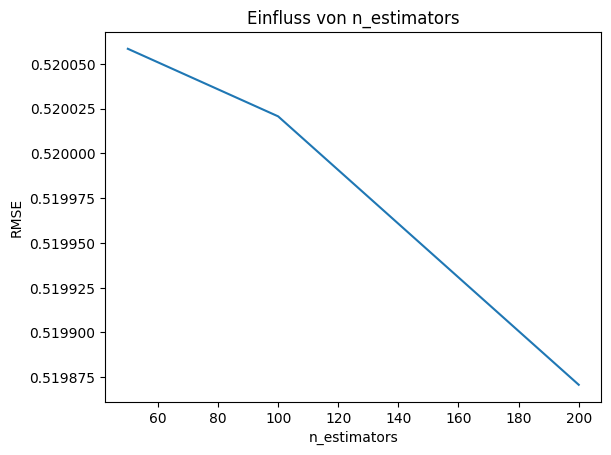

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt

# -------------------
# Data Split
# -------------------
X = df.drop(columns=["rating"])
y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -------------------
# Pipeline
# -------------------
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# -------------------
# GridSearch
# -------------------
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# -------------------
# Best Model Evaluation
# -------------------
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("Best Params:", grid.best_params_)
print("MAE:", mae)
print("RMSE:", rmse)

# -------------------
# Plot: n_estimators Einfluss
# -------------------
results = pd.DataFrame(grid.cv_results_)

plot_data = results.groupby("param_model__n_estimators")["mean_test_score"].mean()

plt.figure()
plt.plot(plot_data.index, -plot_data.values)
plt.xlabel("n_estimators")
plt.ylabel("RMSE")
plt.title("Einfluss von n_estimators")
plt.show()

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

# Features / Target
X = df.drop(columns=["rating"])
y = df["rating"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -------------------
# Ridge Modell
# -------------------
ridge_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("poly", PolynomialFeatures(degree=3)),
    ("model", Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)


# -------------------
# Lasso Modell
# -------------------
lasso_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("poly", PolynomialFeatures(degree=3)),
    ("model", Lasso(alpha=0.1, max_iter=10000))
])

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = root_mean_squared_error(y_test, y_pred_lasso)


# -------------------
# Ergebnisse
# -------------------
print("=== Ridge Regression ===")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)

print("\n=== Lasso Regression ===")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)

=== Ridge Regression ===
MAE: 0.43634658111827856
RMSE: 0.6858743575423323

=== Lasso Regression ===
MAE: 0.47829562730628933
RMSE: 0.7717456625770631


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

# Split
X = df.drop(columns=["rating"])
y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),  # 2 Layer
        activation="relu",
        solver="adam",
        alpha=0.001,                 # Regularisierung!
        max_iter=500,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

MAE: 0.3588113036194041
RMSE: 0.5495238434902097
